In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report


In [6]:
# Step 1: Load dataset
# Keras has MNIST built-in, which makes loading easy
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()


In [8]:
# Step 2: Preprocessing
# Normalization: Scale pixel values to be between 0 and 1
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# Encoding categorical data: Convert labels to one-hot encoding
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)



In [10]:
# Step 3: Dataset Split (Train-Test Set)
# Note: The Keras dataset is already split into train and test. 
# We will create a validation split during the training step.


In [14]:
from tensorflow.keras import Input

model_clf = Sequential([
    Input(shape=(28, 28)),   # <-- NEW (recommended)
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [16]:
# Step 4.1: Choose hyperparameters
LEARNING_RATE = 0.001
EPOCHS = 10
BATCH_SIZE = 32

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model_clf.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])



In [18]:
# Step 5: Train the network
history_clf = model_clf.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2, # Uses 20% of training data for validation
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8603 - loss: 0.4902 - val_accuracy: 0.9577 - val_loss: 0.1439
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9635 - loss: 0.1212 - val_accuracy: 0.9627 - val_loss: 0.1243
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9755 - loss: 0.0803 - val_accuracy: 0.9690 - val_loss: 0.1007
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9829 - loss: 0.0560 - val_accuracy: 0.9681 - val_loss: 0.1136
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9866 - loss: 0.0438 - val_accuracy: 0.9709 - val_loss: 0.1065
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9896 - loss: 0.0323 - val_accuracy: 0.9696 - val_loss: 0.1144
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9912 - loss: 0.0260 - val_accuracy: 0.9710 - val_loss: 0.1105
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9919 - loss: 0.0244 

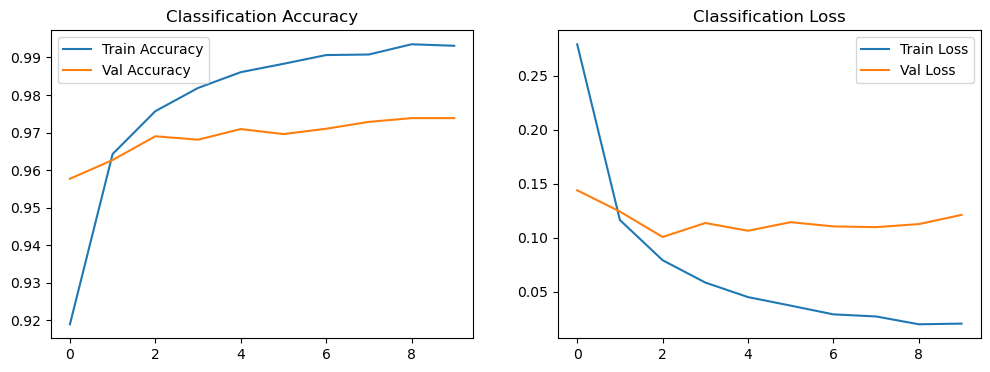

In [20]:
# Plot Accuracy and Loss curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_clf.history['accuracy'], label='Train Accuracy')
plt.plot(history_clf.history['val_accuracy'], label='Val Accuracy')
plt.title('Classification Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_clf.history['loss'], label='Train Loss')
plt.plot(history_clf.history['val_loss'], label='Val Loss')
plt.title('Classification Loss')
plt.legend()
plt.show()



In [22]:
# Step 6: Evaluate model performance
test_loss, test_acc = model_clf.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion Matrix, Precision, Recall
y_pred_probs = model_clf.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_raw, y_pred_classes))
print("\nClassification Report (Precision, Recall, F1):")
print(classification_report(y_test_raw, y_pred_classes))


Test Accuracy: 0.9737
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Confusion Matrix:
[[ 969    1    2    0    1    2    2    0    1    2]
 [   0 1120    5    1    0    1    3    1    4    0]
 [   3    0 1017    3    0    1    2    4    2    0]
 [   0    0    9  982    0   13    0    3    1    2]
 [   0    1    7    1  932    0   10    6    5   20]
 [   2    0    0    2    0  881    2    1    1    3]
 [   5    2    0    0    1   18  927    0    4    1]
 [   1    5   14    1    0    0    0  997    3    7]
 [   2    0    9    6    1   17    1    8  928    2]
 [   1    2    0    5    3    9    0    4    1  984]]

Classification Report (Precision, Recall, F1):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.99      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.99      0.95      0.97       982
           5  

In [24]:
# Step 7: Predict (Inference) for new unseen dataset
# Simulating a new unseen image prediction
new_unseen_image = X_test[0:1] 
prediction = model_clf.predict(new_unseen_image)
predicted_digit = np.argmax(prediction)
print(f"\nPredicted digit for new image: {predicted_digit}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

Predicted digit for new image: 7
